In [1]:
import time

import numpy as np
from matplotlib import pyplot as plt
from torch import Tensor
from torch.nn import functional as F

from common import G2OpGymEnv, BusConnectivityGraphObsSpace
from nri import Encoder, GumbelSoftmax
from nri import prior_from_env
from nri.agent.graphormer.GraphormerEncoder import GraphormerNRIEncoder
from nri.agent.pretrain_encoder import create_dataset, GraphDataset
from nri.agent.pretrain_encoder import train
from visualization import PlottingArgs, visualize_graph
from visualization import get_node_styles

In [2]:
env = G2OpGymEnv(
    obs_space_creation=lambda e: BusConnectivityGraphObsSpace(e.observation_space, normalization_boundaries={
        "active_power_forecast": [-122.4, 116.666],
        "active_power": [-122.4, 116.666],
        "reactive_power_forecast": [-85.7, 107.228],
        "reactive_power": [-85.7, 107.228],
        "voltage": [-142.1, 142.1],
        "voltage_angle": [-14.212, 1.246],
        "current": [0, 1512],
        "rho": [0, 1]
    }))
eps = 0.0000001
prior_for_graph_edges = 0.9
ds_size = 1000

# create prior and dataset
prior = prior_from_env(prior_for_graph_edges, env)
ds: GraphDataset = create_dataset(env, prior, ds_size)

2025-11-21 15:20:52,213 - common.constants - INFO - Using graph observation space with 57 nodes, ≤ 244 edges and 8 features per node (active_power_forecast, reactive_power_forecast, active_power, reactive_power, voltage, voltage_angle, current, rho).
2025-11-21 15:20:52,222 - common.constants - INFO - Prior for graph edges: tensor([0.9000, 0.1000]), Prior for non graph edges: tensor([0.0541, 0.9459])
Create dataset: 100%|██████████| 1000/1000 [00:01<00:00, 728.37it/s]


In [6]:
graphormer_encoder = GraphormerNRIEncoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_edge_types=2, max_degree=7, max_path_distance=9)
nri_encoder = Encoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_edge_types=2, dropout_prob=0.0)

results = {
    "Graphormer": {"loss": [], "time": -1},
    "NRI":  {"loss": [], "time": -1},
}

encoders = {
    "Graphormer": graphormer_encoder,
    "NRI": nri_encoder
}

for name, encoder in encoders.items():
    start = time.time()
    results[name]["loss"] = train(encoder, ds, num_epochs=50)
    results[name]["time"] = (time.time() - start)


2025-11-21 14:52:53,277 - common.constants - INFO - Epoch 0, Loss: 0.00691719, Max Grads: 0.01, logits max: 1.00, 
2025-11-21 14:52:54,292 - common.constants - INFO - Epoch 1, Loss: 0.00463766, Max Grads: 0.00, logits max: 1.00, 
2025-11-21 14:52:55,410 - common.constants - INFO - Epoch 2, Loss: 0.00459900, Max Grads: 0.00, logits max: 1.00, 
2025-11-21 14:52:56,497 - common.constants - INFO - Epoch 3, Loss: 0.00454074, Max Grads: 0.00, logits max: 1.00, 
2025-11-21 14:52:57,565 - common.constants - INFO - Epoch 4, Loss: 0.00429146, Max Grads: 0.10, logits max: 1.00, 
2025-11-21 14:52:58,653 - common.constants - INFO - Epoch 5, Loss: 0.00311218, Max Grads: 0.03, logits max: 1.00, 
2025-11-21 14:52:59,646 - common.constants - INFO - Epoch 6, Loss: 0.00064060, Max Grads: 0.01, logits max: 1.00, 
2025-11-21 14:53:00,689 - common.constants - INFO - Epoch 7, Loss: 0.00025475, Max Grads: 0.01, logits max: 1.00, 
2025-11-21 14:53:01,689 - common.constants - INFO - Epoch 8, Loss: 0.00013175, M

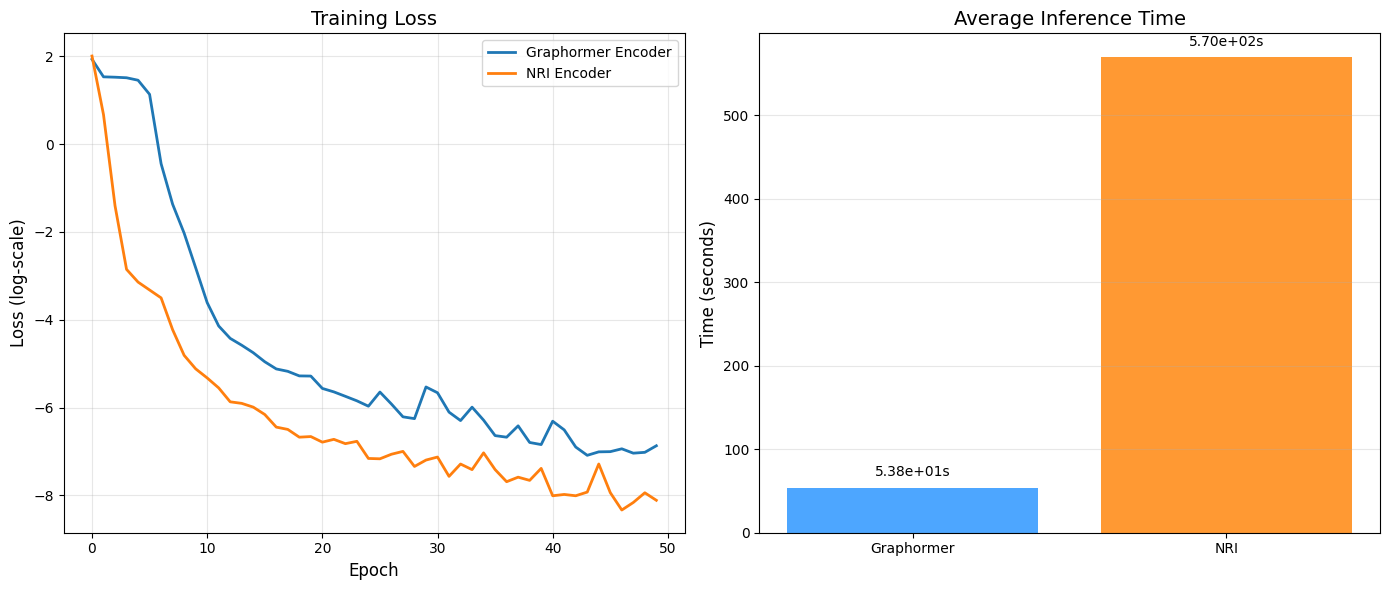

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ----- Loss Plot -----
axes[0].plot(np.log(np.array(results["Graphormer"]["loss"]) + eps), label="Graphormer Encoder", linewidth=2)
axes[0].plot(np.log(np.array(results["NRI"]["loss"]) + eps), label="NRI Encoder", linewidth=2)

axes[0].set_title("Training Loss", fontsize=14)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss (log-scale)", fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend()

# ----- Inference Time Bar Chart -----
methods = ["Graphormer", "NRI"]
values = [results["Graphormer"]["time"], results["NRI"]["time"]]

bars = axes[1].bar(methods, values, color=["#4da6ff", "#ff9933"])

# Add exact value labels above bars
for bar, val in zip(bars, values):
    axes[1].annotate(f"{val:.2e}s",
                     xy=(bar.get_x() + bar.get_width() / 2, val),
                     xytext=(0, 6),
                     textcoords="offset points",
                     ha="center", va="bottom",
                     fontsize=10)

axes[1].set_title("Average Inference Time", fontsize=14)
axes[1].set_ylabel("Time (seconds)", fontsize=12)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Graphormer encoder is able to approximate the prior equally well as the NRI Encoder. Since it has a more general understanding of the structure of the powergrid, it is likely better suited to make predictions for latent graph structures. For small learning rates we can observe a slower convergence than for the NRI encoder initially.

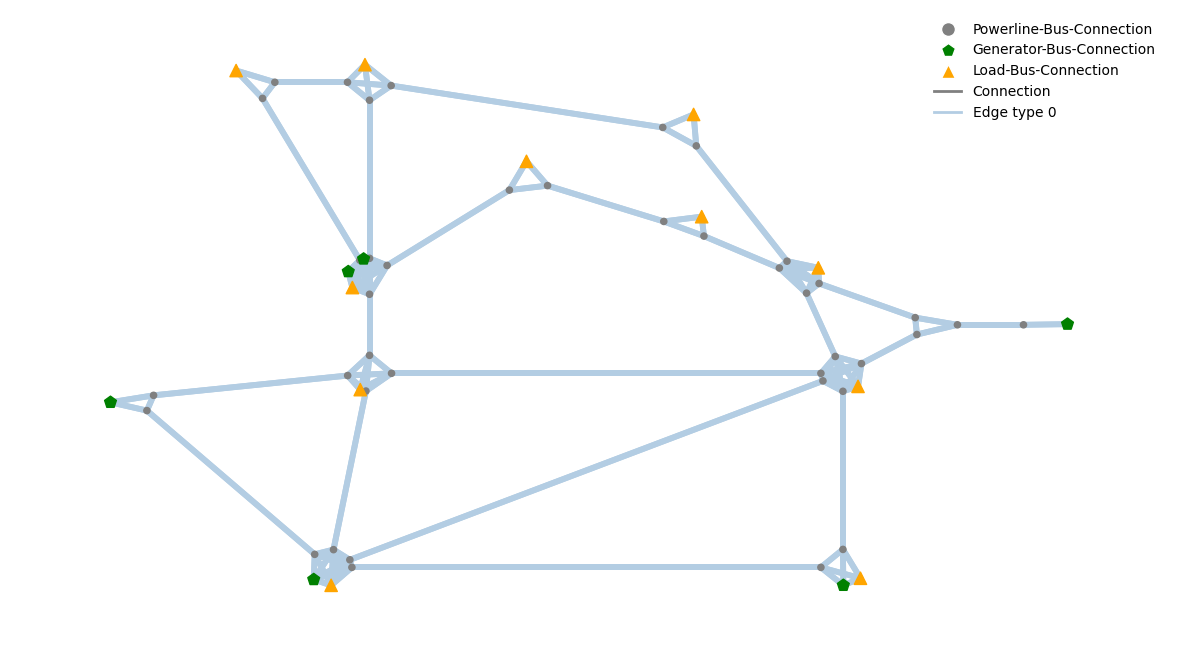

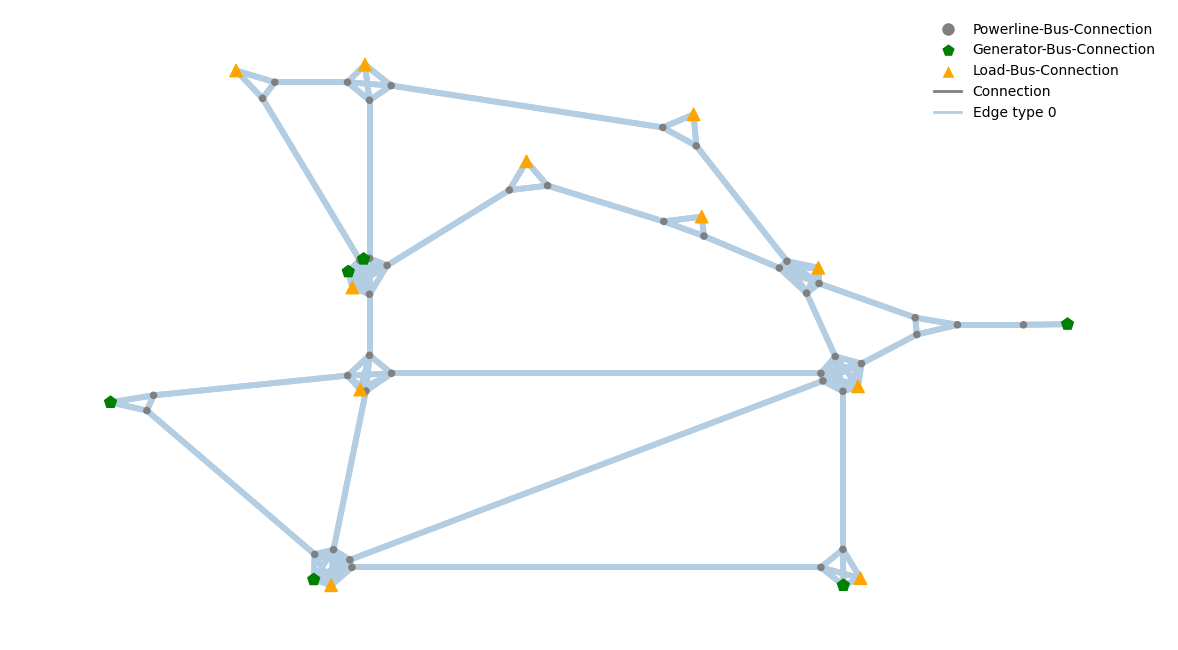

In [11]:
sample = ds.get(0)
gumbel = GumbelSoftmax()

x = sample.x
powerline_edge_index = sample.edge_index

for enc in [graphormer_encoder, nri_encoder]:
    encoder_logits: Tensor = enc.forward(x=x, powerline_edge_index=powerline_edge_index) # [E, K]
    p_z_given_x: Tensor = F.softmax(encoder_logits, dim=-1).detach().cpu().numpy() # [E, K]
    p_one_hot: Tensor = gumbel.forward(x=encoder_logits).detach().cpu().numpy() # [E, K]

    plotting_args = PlottingArgs(
        env.observation_space.num_nodes,
        get_node_styles(env._g2op_env, env.observation_space.__class__),
        powerline_edge_index=powerline_edge_index,
        latent_edge_probs=p_z_given_x,
    )
    visualize_graph(plotting_args)

In [12]:
loss_curves_per_run = []
n_runs = 10
for i in range(n_runs):
    graphormer_encoder_short = GraphormerNRIEncoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_edge_types=2, max_degree=7, max_path_distance=9)
    loss_curve = train(graphormer_encoder_short, ds, num_epochs=50)
    loss_curves_per_run.append(loss_curve)

2025-11-21 15:04:33,600 - common.constants - INFO - Epoch 0, Loss: 0.00637502, Max Grads: 0.01, logits max: 1.00, 
2025-11-21 15:04:34,676 - common.constants - INFO - Epoch 1, Loss: 0.00464281, Max Grads: 0.00, logits max: 1.00, 
2025-11-21 15:04:35,744 - common.constants - INFO - Epoch 2, Loss: 0.00438440, Max Grads: 0.02, logits max: 1.00, 
2025-11-21 15:04:36,876 - common.constants - INFO - Epoch 3, Loss: 0.00322815, Max Grads: 0.05, logits max: 1.00, 
2025-11-21 15:04:38,066 - common.constants - INFO - Epoch 4, Loss: 0.00076264, Max Grads: 0.01, logits max: 1.00, 
2025-11-21 15:04:39,145 - common.constants - INFO - Epoch 5, Loss: 0.00038268, Max Grads: 0.02, logits max: 1.00, 
2025-11-21 15:04:40,668 - common.constants - INFO - Epoch 6, Loss: 0.00020329, Max Grads: 0.01, logits max: 1.00, 
2025-11-21 15:04:42,017 - common.constants - INFO - Epoch 7, Loss: 0.00011266, Max Grads: 0.01, logits max: 1.00, 
2025-11-21 15:04:43,359 - common.constants - INFO - Epoch 8, Loss: 0.00006470, M

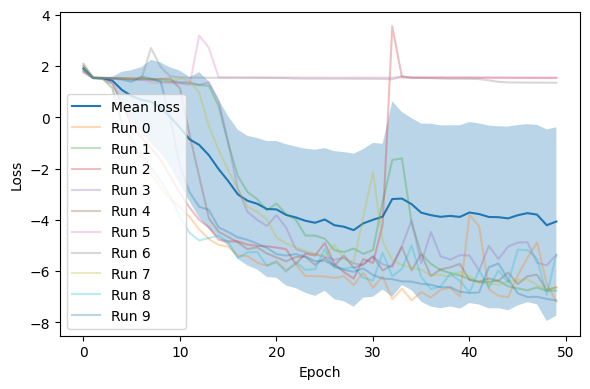

In [13]:
loss_arr = np.log(np.array(loss_curves_per_run) + eps)
mean_loss = loss_arr.mean(axis=0)
std_loss = loss_arr.std(axis=0)
epochs = np.arange(loss_arr.shape[1])

plt.figure(figsize=(6,4))
plt.plot(epochs, mean_loss, label="Mean loss")
plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.3)
for i, run in enumerate(loss_arr):
    plt.plot(epochs, run, label=f"Run {i}", alpha=0.3)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()